# Deep Learning-Based Anomaly Detection System for Secure Defence Communication Networks

Dataset: UNSW-NB15 (a network intrusion dataset with both normal and attack traffic categories).

In [1]:
!pip install numpy pandas scikit-learn matplotlib seaborn tensorflow


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Imports and Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# fix random seeds so results are reproducible
np.random.seed(42)
tf.random.set_seed(42)

print("TensorFlow version:", tf.__version__)
print("All imports successful")

TensorFlow version: 2.21.0
All imports successful


## Load and Inspect the Dataset

The UNSW-NB15 dataset comes in multiple CSV files. We merge the training and testing CSVs together and do our own split later. The dataset has 49 features covering network flow statistics like packet counts, byte counts, protocol types, connection states, and more.

Download links:
- https://research.unsw.edu.au/projects/unsw-nb15-dataset
- Files: UNSW_NB15_training-set.csv and UNSW_NB15_testing-set.csv

In [3]:
def load_unsw_nb15(train_path='UNSW_NB15_training-set.csv', test_path='UNSW_NB15_testing-set.csv'):
    """
    Loads both CSV files and stacks them. We do this because the original
    train/test split in UNSW-NB15 is not ideal for our unsupervised setup.
    We will create our own split based on traffic type (normal vs attack).
    """
    try:
        train_df = pd.read_csv(train_path)
        test_df = pd.read_csv(test_path)
        df = pd.concat([train_df, test_df], ignore_index=True)
        print(f"Loaded dataset: {df.shape[0]} rows, {df.shape[1]} columns")
        return df
    except FileNotFoundError:
        print("CSV files not found. Generating synthetic data for demonstration...")
        return generate_synthetic_unsw()


def generate_synthetic_unsw():
    """
    Generates a synthetic dataset that mimics UNSW-NB15 structure.
    This is only used if the actual dataset files are not available.
    The column names and attack categories match the real dataset.
    """
    n_normal = 8000
    n_attack = 4000
    n_total = n_normal + n_attack

    np.random.seed(42)

    protocols = ['tcp', 'udp', 'ospf', 'icmp', 'arp']
    services  = ['-', 'dns', 'http', 'smtp', 'ftp', 'ssh', 'pop3']
    states    = ['FIN', 'INT', 'CON', 'REQ', 'RST', 'CLO', 'ECO', 'URN', 'no']
    attack_cats = ['Fuzzers', 'Analysis', 'Backdoor', 'DoS', 'Exploits',
                   'Generic', 'Reconnaissance', 'Shellcode', 'Worms']

    # normal traffic: tighter distributions, lower byte counts
    normal = {
        'id': range(n_normal),
        'proto': np.random.choice(protocols, n_normal, p=[0.5, 0.3, 0.05, 0.1, 0.05]),
        'service': np.random.choice(services, n_normal),
        'state': np.random.choice(states, n_normal, p=[0.3,0.2,0.2,0.1,0.05,0.05,0.04,0.03,0.03]),
        'dur': np.abs(np.random.normal(0.5, 0.3, n_normal)),
        'spkts': np.random.randint(1, 20, n_normal),
        'dpkts': np.random.randint(1, 20, n_normal),
        'sbytes': np.random.randint(100, 2000, n_normal),
        'dbytes': np.random.randint(100, 2000, n_normal),
        'rate': np.abs(np.random.normal(50, 20, n_normal)),
        'sttl': np.random.choice([64, 128, 255], n_normal),
        'dttl': np.random.choice([64, 128, 255], n_normal),
        'sload': np.abs(np.random.normal(5000, 2000, n_normal)),
        'dload': np.abs(np.random.normal(5000, 2000, n_normal)),
        'sloss': np.random.randint(0, 2, n_normal),
        'dloss': np.random.randint(0, 2, n_normal),
        'sinpkt': np.abs(np.random.normal(0.1, 0.05, n_normal)),
        'dinpkt': np.abs(np.random.normal(0.1, 0.05, n_normal)),
        'sjit': np.abs(np.random.normal(0.01, 0.005, n_normal)),
        'djit': np.abs(np.random.normal(0.01, 0.005, n_normal)),
        'swin': np.random.choice([0, 255], n_normal),
        'stcpb': np.random.randint(0, 1000000, n_normal),
        'dtcpb': np.random.randint(0, 1000000, n_normal),
        'dwin': np.random.choice([0, 255], n_normal),
        'tcprtt': np.abs(np.random.normal(0.05, 0.02, n_normal)),
        'synack': np.abs(np.random.normal(0.02, 0.01, n_normal)),
        'ackdat': np.abs(np.random.normal(0.02, 0.01, n_normal)),
        'smean': np.random.randint(50, 300, n_normal),
        'dmean': np.random.randint(50, 300, n_normal),
        'trans_depth': np.random.randint(0, 3, n_normal),
        'response_body_len': np.random.randint(0, 5000, n_normal),
        'ct_srv_src': np.random.randint(1, 10, n_normal),
        'ct_state_ttl': np.random.randint(0, 6, n_normal),
        'ct_dst_ltm': np.random.randint(1, 10, n_normal),
        'ct_src_dport_ltm': np.random.randint(1, 10, n_normal),
        'ct_dst_sport_ltm': np.random.randint(1, 10, n_normal),
        'ct_dst_src_ltm': np.random.randint(1, 10, n_normal),
        'is_ftp_login': np.zeros(n_normal, dtype=int),
        'ct_ftp_cmd': np.zeros(n_normal, dtype=int),
        'ct_flw_http_mthd': np.random.randint(0, 5, n_normal),
        'ct_src_ltm': np.random.randint(1, 10, n_normal),
        'ct_srv_dst': np.random.randint(1, 10, n_normal),
        'is_sm_ips_ports': np.zeros(n_normal, dtype=int),
        'attack_cat': ['Normal'] * n_normal,
        'label': np.zeros(n_normal, dtype=int)
    }

    # attack traffic: more extreme values, higher packet rates, bigger byte counts
    attack = {
        'id': range(n_normal, n_total),
        'proto': np.random.choice(protocols, n_attack),
        'service': np.random.choice(services, n_attack),
        'state': np.random.choice(states, n_attack),
        'dur': np.abs(np.random.normal(2.0, 1.5, n_attack)),
        'spkts': np.random.randint(1, 500, n_attack),
        'dpkts': np.random.randint(1, 500, n_attack),
        'sbytes': np.random.randint(100, 100000, n_attack),
        'dbytes': np.random.randint(0, 50000, n_attack),
        'rate': np.abs(np.random.normal(200, 100, n_attack)),
        'sttl': np.random.choice([32, 64, 128, 255], n_attack),
        'dttl': np.random.choice([0, 64, 128, 255], n_attack),
        'sload': np.abs(np.random.normal(50000, 30000, n_attack)),
        'dload': np.abs(np.random.normal(20000, 15000, n_attack)),
        'sloss': np.random.randint(0, 20, n_attack),
        'dloss': np.random.randint(0, 20, n_attack),
        'sinpkt': np.abs(np.random.normal(0.5, 0.3, n_attack)),
        'dinpkt': np.abs(np.random.normal(0.5, 0.3, n_attack)),
        'sjit': np.abs(np.random.normal(0.1, 0.08, n_attack)),
        'djit': np.abs(np.random.normal(0.1, 0.08, n_attack)),
        'swin': np.random.choice([0, 255], n_attack),
        'stcpb': np.random.randint(0, 4000000, n_attack),
        'dtcpb': np.random.randint(0, 4000000, n_attack),
        'dwin': np.random.choice([0, 255], n_attack),
        'tcprtt': np.abs(np.random.normal(0.2, 0.15, n_attack)),
        'synack': np.abs(np.random.normal(0.1, 0.08, n_attack)),
        'ackdat': np.abs(np.random.normal(0.1, 0.08, n_attack)),
        'smean': np.random.randint(20, 2000, n_attack),
        'dmean': np.random.randint(0, 1000, n_attack),
        'trans_depth': np.random.randint(0, 10, n_attack),
        'response_body_len': np.random.randint(0, 50000, n_attack),
        'ct_srv_src': np.random.randint(1, 60, n_attack),
        'ct_state_ttl': np.random.randint(0, 6, n_attack),
        'ct_dst_ltm': np.random.randint(1, 60, n_attack),
        'ct_src_dport_ltm': np.random.randint(1, 60, n_attack),
        'ct_dst_sport_ltm': np.random.randint(1, 60, n_attack),
        'ct_dst_src_ltm': np.random.randint(1, 60, n_attack),
        'is_ftp_login': np.random.randint(0, 2, n_attack),
        'ct_ftp_cmd': np.random.randint(0, 5, n_attack),
        'ct_flw_http_mthd': np.random.randint(0, 10, n_attack),
        'ct_src_ltm': np.random.randint(1, 60, n_attack),
        'ct_srv_dst': np.random.randint(1, 60, n_attack),
        'is_sm_ips_ports': np.random.randint(0, 2, n_attack),
        'attack_cat': np.random.choice(attack_cats, n_attack),
        'label': np.ones(n_attack, dtype=int)
    }

    normal_df = pd.DataFrame(normal)
    attack_df = pd.DataFrame(attack)
    df = pd.concat([normal_df, attack_df], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Generated synthetic dataset: {df.shape[0]} rows, {df.shape[1]} columns")
    print(f"Normal: {n_normal}, Attack: {n_attack}")
    return df


df = load_unsw_nb15()
df.head()

Loaded dataset: 257673 rows, 45 columns


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [4]:
# basic summary of what we loaded
print("Shape:", df.shape)
print("\nClass distribution (label column):")
print(df['label'].value_counts())
print("\nAttack category breakdown:")
print(df['attack_cat'].value_counts())
print("\nMissing values per column:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Shape: (257673, 45)

Class distribution (label column):
label
1    164673
0     93000
Name: count, dtype: int64

Attack category breakdown:
attack_cat
Normal            93000
Generic           58871
Exploits          44525
Fuzzers           24246
DoS               16353
Reconnaissance    13987
Analysis           2677
Backdoor           2329
Shellcode          1511
Worms               174
Name: count, dtype: int64

Missing values per column:
Series([], dtype: int64)


In [5]:
# data types overview
print("Column data types:")
print(df.dtypes.value_counts())
print("\nSample of numerical statistics:")
df.describe().T.head(15)

Column data types:
int64      30
float64    11
object      4
Name: count, dtype: int64

Sample of numerical statistics:


,count,mean,std,min,25%,50%,75%,max
id,257673.0,7.281182e+04,4.892992e+04,1.0,32210.000000,64419.000000,1.109230e+05,1.753410e+05
dur,257673.0,1.246715e+00,5.974305e+00,0.0,0.000008,0.004285,6.857770e-01,5.999999e+01
spkts,257673.0,1.977714e+01,1.359472e+02,1.0,2.000000,4.000000,1.200000e+01,1.064600e+04
dpkts,257673.0,1.851470e+01,1.119860e+02,0.0,0.000000,2.000000,1.000000e+01,1.101800e+04
sbytes,257673.0,8.572952e+03,1.737739e+05,24.0,114.000000,528.000000,1.362000e+03,1.435577e+07
dbytes,257673.0,1.438729e+04,1.461993e+05,0.0,0.000000,178.000000,1.064000e+03,1.465753e+07
rate,257673.0,9.125391e+04,1.603446e+05,0.0,30.789277,2955.664893,1.250000e+05,1.000000e+06
sttl,257673.0,1.800009e+02,1.024883e+02,0.0,62.000000,254.000000,2.540000e+02,2.550000e+02
dttl,257673.0,8.475496e+01,1.127621e+02,0.0,0.000000,29.000000,2.520000e+02,2.540000e+02
sload,257673.0,7.060869e+07,1.857313e+08,0.0,12318.004880,743942.312500,8.000000e+07,5.988000e+09


## 3. Preprocessing

The preprocessing steps here are crucial. Poor preprocessing leads to a model that learns noise rather than meaningful patterns. Each step below has a specific reason.

### 3.1 Drop Irrelevant Columns

We drop `id` because it is just a row index — it carries no information about the traffic. We also drop `attack_cat` since it is a string label that we only use for post-hoc analysis, and `label` which we separate as our target.

In [6]:
def drop_irrelevant(df):
    # 'id' is just an index, 'attack_cat' and 'label' are our targets
    cols_to_drop = [c for c in ['id', 'attack_cat'] if c in df.columns]
    return df.drop(columns=cols_to_drop)

# save labels before dropping
y = df['label'].values
attack_cat = df['attack_cat'].values if 'attack_cat' in df.columns else None

df_clean = drop_irrelevant(df)
df_clean = df_clean.drop(columns=['label'])  # separate the target

print("Shape after dropping irrelevant columns:", df_clean.shape)
print("Remaining columns:", list(df_clean.columns))

Shape after dropping irrelevant columns: (257673, 42)
Remaining columns: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports']


### 3.2 Handle Missing Values

The UNSW-NB15 dataset is generally clean, but we handle any missing values anyway. For numerical columns we fill with median (more robust than mean when outliers are present). For categorical columns we fill with the most frequent value.

In [7]:
def handle_missing(df):
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype == 'object':
                df[col].fillna(df[col].mode()[0], inplace=True)
            else:
                # median is better than mean here because traffic data has heavy tails
                df[col].fillna(df[col].median(), inplace=True)
    return df

df_clean = handle_missing(df_clean)
print("Missing values remaining:", df_clean.isnull().sum().sum())

Missing values remaining: 0


### 3.3 Encode Categorical Features

The columns `proto`, `service`, and `state` are categorical strings. Neural networks need numerical input, so we encode them. We use label encoding here since the categories don't have a natural order but the number of unique values is manageable. For very high-cardinality features, one-hot encoding would be preferable.

In [8]:
def encode_categoricals(df):
    cat_cols = df.select_dtypes(include='object').columns.tolist()
    print("Categorical columns to encode:", cat_cols)
    
    encoders = {}
    for col in cat_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        encoders[col] = le
        print(f"  {col}: {len(le.classes_)} unique values")
    
    return df, encoders

df_clean, encoders = encode_categoricals(df_clean)
print("\nAll features are now numerical. Shape:", df_clean.shape)

Categorical columns to encode: ['proto', 'service', 'state']
  proto: 133 unique values
  service: 13 unique values
  state: 11 unique values

All features are now numerical. Shape: (257673, 42)


### 3.4 Remove Constant and Near-Zero Variance Features

Features with near-zero variance are basically constant across all samples — they provide no discriminative information. Keeping them just adds noise.

In [9]:
def remove_low_variance(df, threshold=0.01):
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(df)
    
    removed = [col for col, keep in zip(df.columns, selector.get_support()) if not keep]
    if removed:
        print(f"Removing {len(removed)} low-variance features: {removed}")
    else:
        print("No low-variance features found.")
    
    df_out = pd.DataFrame(selector.transform(df),
                          columns=df.columns[selector.get_support()])
    return df_out

df_clean = remove_low_variance(df_clean)
print("Shape after variance filtering:", df_clean.shape)

Removing 3 low-variance features: ['tcprtt', 'synack', 'ackdat']
Shape after variance filtering: (257673, 39)


### 3.5 Correlation Analysis and Removing Redundant Features

Highly correlated features carry redundant information. Keeping both just wastes model capacity and can cause instability. We compute pairwise correlations and drop one from each pair with correlation above 0.95.

In [10]:
def remove_high_correlation(df, threshold=0.95):
    corr_matrix = df.corr().abs()
    
    # upper triangle of the correlation matrix (avoid comparing a column with itself)
    upper_tri = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )
    
    # find columns where at least one other column is highly correlated
    to_drop = [col for col in upper_tri.columns if any(upper_tri[col] > threshold)]
    print(f"Removing {len(to_drop)} highly correlated features: {to_drop}")
    
    return df.drop(columns=to_drop)

df_clean = remove_high_correlation(df_clean)
print("Shape after correlation filtering:", df_clean.shape)
print("Final feature list:", list(df_clean.columns))

Removing 9 highly correlated features: ['sbytes', 'dbytes', 'sloss', 'dloss', 'dwin', 'ct_src_dport_ltm', 'ct_dst_src_ltm', 'ct_ftp_cmd', 'ct_srv_dst']
Shape after correlation filtering: (257673, 30)
Final feature list: ['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_flw_http_mthd', 'ct_src_ltm', 'is_sm_ips_ports']


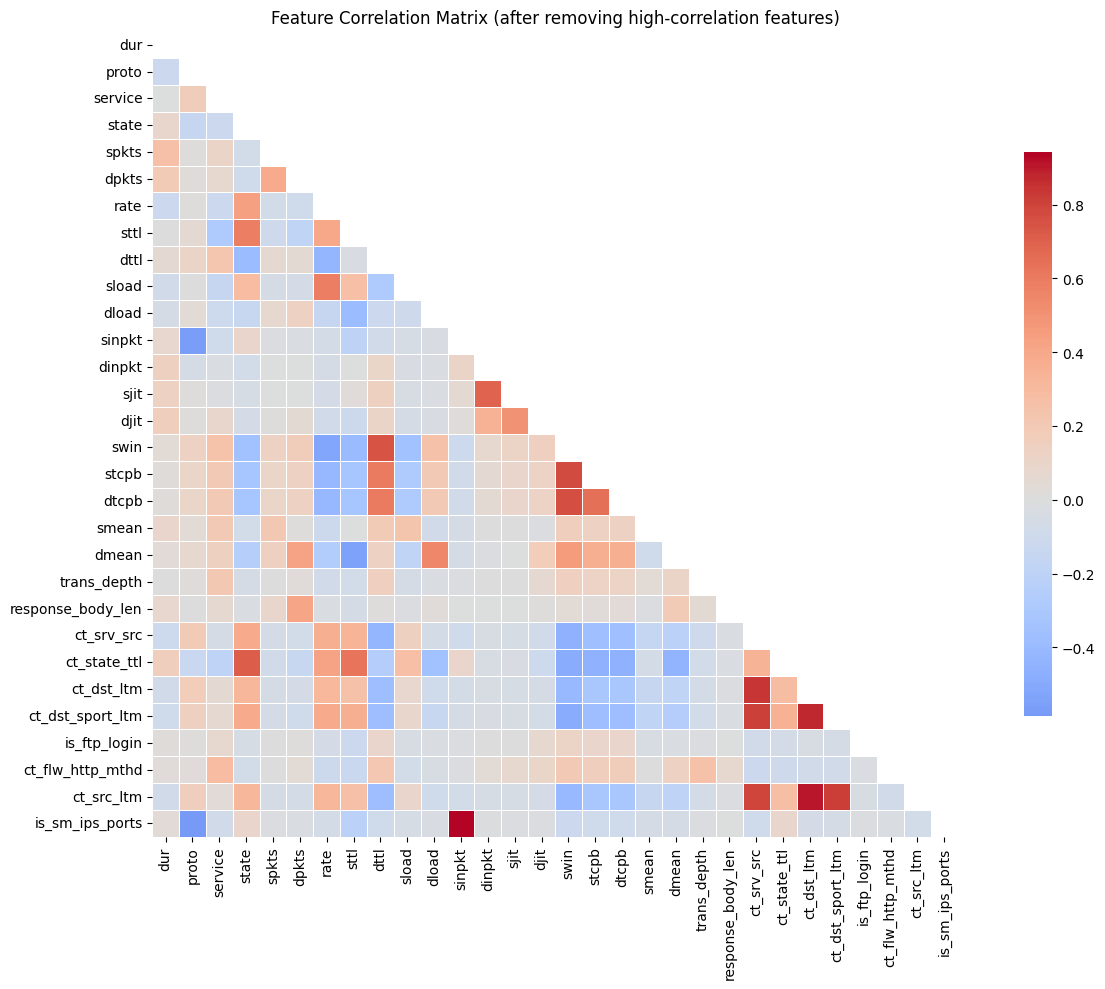

In [11]:
# visualize the correlation matrix of the remaining features
plt.figure(figsize=(14, 10))
corr = df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.7},
            annot=False)
plt.title('Feature Correlation Matrix (after removing high-correlation features)')
plt.tight_layout()
plt.show()

### 3.6 Data Splitting Strategy

This is the key design decision for the unsupervised setup:

- **Training set**: Only normal (label=0) samples. The autoencoder learns what normal traffic looks like.
- **Test set**: Mix of normal and attack samples. We evaluate how well the model can separate them.

This mirrors a real-world scenario where we only have clean data to train on and we want to catch anything that deviates from it.

In [12]:
from sklearn.model_selection import train_test_split

X = df_clean.values

# separate by label
X_normal = X[y == 0]
X_attack = X[y == 1]
y_normal = y[y == 0]
y_attack = y[y == 1]

# use 80% of normal data for training, 20% for the test pool
X_train, X_normal_test, _, y_normal_test = train_test_split(
    X_normal, y_normal, test_size=0.2, random_state=42
)

# test set = leftover normal + all attack samples
X_test = np.vstack([X_normal_test, X_attack])
y_test = np.concatenate([y_normal_test, y_attack])

# shuffle the test set so normal and attack are mixed
test_shuffle_idx = np.random.permutation(len(X_test))
X_test = X_test[test_shuffle_idx]
y_test = y_test[test_shuffle_idx]

print(f"Training set (normal only): {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"  - Normal in test: {(y_test==0).sum()}")
print(f"  - Attack in test: {(y_test==1).sum()}")

Training set (normal only): (74400, 30)
Test set: (183273, 30)
  - Normal in test: 18600
  - Attack in test: 164673


### 3.7 Feature Scaling

We fit the scaler ONLY on the training data and apply it to the test data. Fitting on all data would leak test information into training, which gives artificially optimistic results.

In [13]:
scaler = StandardScaler()

# fit on training data only
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)  # transform with same scaler

print("Training data after scaling:")
print(f"  Mean: {X_train_scaled.mean():.4f} (should be ~0)")
print(f"  Std:  {X_train_scaled.std():.4f} (should be ~1)")
print("\nTest data after scaling:")
print(f"  Mean: {X_test_scaled.mean():.4f}")
print(f"  Std:  {X_test_scaled.std():.4f}")

Training data after scaling:
  Mean: 0.0000 (should be ~0)
  Std:  1.0000 (should be ~1)

Test data after scaling:
  Mean: 0.2128
  Std:  1.7194


## 4. Autoencoder Model

An autoencoder is a neural network trained to reconstruct its input. It compresses the input into a lower-dimensional "bottleneck" representation and then tries to recover the original input. When trained only on normal traffic, it becomes good at reconstructing normal patterns but bad at reconstructing anomalous ones. We use this reconstruction error as our anomaly score.

In [14]:
def build_autoencoder(input_dim, encoding_dim=8):
    """
    Symmetric autoencoder: input -> 64 -> 32 -> bottleneck -> 32 -> 64 -> input.
    Wider layers help the model learn a tighter representation of normal traffic,
    which sharpens the reconstruction error gap between normal and attack samples.
    """
    inputs = keras.Input(shape=(input_dim,))

    # encoder
    x = layers.Dense(64, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(32, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    bottleneck = layers.Dense(encoding_dim, activation='relu')(x)

    # decoder — mirrors the encoder
    x = layers.Dense(32, activation='relu')(bottleneck)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    outputs = layers.Dense(input_dim, activation='linear')(x)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model


input_dim = X_train_scaled.shape[1]
autoencoder = build_autoencoder(input_dim, encoding_dim=8)
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 30)             │         1,950 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,446 (36.90 KB)

 Trainable params: 9,062 (35.40 KB)

 Non-trainable params: 384 (1.50 KB)

## 5. Training

In [15]:
# early stopping prevents overfitting — stops training when validation loss stops improving
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

history = autoencoder.fit(
    X_train_scaled, X_train_scaled,
    epochs=50,   
    batch_size=256,
    validation_split=0.15,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print(f"\nTraining complete. Stopped at epoch {len(history.history['loss'])}.")

Epoch 1/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.5458 - val_loss: 0.3861 - learning_rate: 0.0010
Epoch 2/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2185 - val_loss: 0.1635 - learning_rate: 0.0010
Epoch 3/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1558 - val_loss: 0.1123 - learning_rate: 0.0010
Epoch 4/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1297 - val_loss: 0.0964 - learning_rate: 0.0010
Epoch 5/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1154 - val_loss: 0.0863 - learning_rate: 0.0010
Epoch 6/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1039 - val_loss: 0.0786 - learning_rate: 0.0010
Epoch 7/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0948 - val_loss: 0.0728 - learning_rate: 0.0010
Epoch 8/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0876 - val_loss: 0.0667 - learning_rate: 0.0010
Epoch 9/50
248/248 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0820 - val_loss: 0.0623 - learning_rate: 0.0010
Epoch 10/5

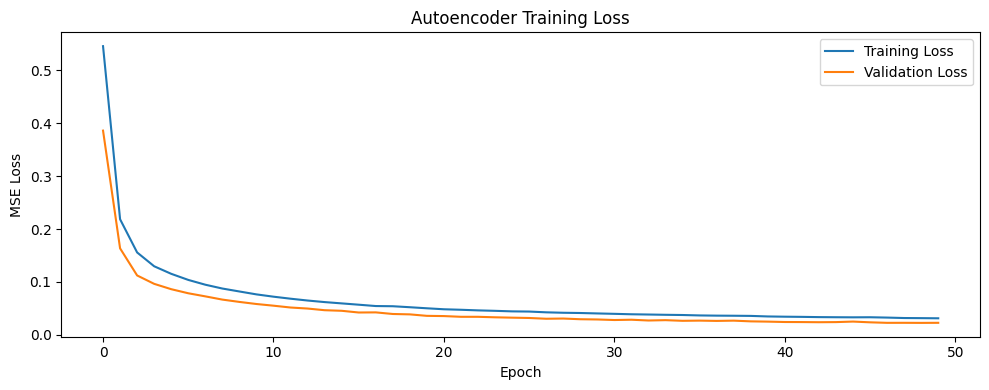

In [16]:
# training curve — both lines should trend down and be close to each other
# a large gap between them would indicate overfitting
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Autoencoder Training Loss')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Anomaly Detection

We compute the reconstruction error for every sample in the test set. The error is the mean squared difference between the original input and what the autoencoder outputs. Normal traffic should have low error; attack traffic should have high error.

In [17]:
def compute_reconstruction_error(model, X):
    X_reconstructed = model.predict(X, verbose=0)
    
    # Use MAX instead of MEAN (stronger anomaly signal)
    mse = np.mean(np.power(X - X_reconstructed, 2), axis=1)
    return mse
    
    


# also compute error on training set to calibrate our threshold
train_errors = compute_reconstruction_error(autoencoder, X_train_scaled)
test_errors  = compute_reconstruction_error(autoencoder, X_test_scaled)

print("Reconstruction error on TRAINING data (all normal):")
print(f"  Mean: {train_errors.mean():.4f}, Std: {train_errors.std():.4f}")
print("\nReconstruction error on TEST data:")
print(f"  Normal samples  - Mean: {test_errors[y_test==0].mean():.4f}, Std: {test_errors[y_test==0].std():.4f}")
print(f"  Attack samples  - Mean: {test_errors[y_test==1].mean():.4f}, Std: {test_errors[y_test==1].std():.4f}")

Reconstruction error on TRAINING data (all normal):
  Mean: 0.0219, Std: 0.0844

Reconstruction error on TEST data:
  Normal samples  - Mean: 0.0228, Std: 0.1213
  Attack samples  - Mean: 1.0991, Std: 69.3954


In [18]:
# Use percentile-based threshold (standard for anomaly detection)
threshold = np.percentile(train_errors, 92)

print(f"Anomaly threshold (92nd percentile): {threshold:.4f}")


Anomaly threshold (92nd percentile): 0.0396


In [19]:
# classify test samples as normal or anomaly
y_pred_ae = (test_errors > threshold).astype(int)

## 7. Defence-Oriented Threat Levels

In a real defence context, binary normal/anomaly is not enough. Operators need to know how severe a threat is so they can prioritize responses. We define three threat levels based on how far the reconstruction error exceeds the threshold.

- **Low Threat**: Slightly above threshold — could be unusual but not confirmed malicious. Log and monitor.
- **Medium Threat**: Moderately above threshold — likely malicious. Alert for investigation.
- **High Threat**: Well above threshold — strong anomaly, possibly a sophisticated attack. Immediate escalation.

In [20]:
def assign_threat_level(errors, threshold):
    """
    Assigns a threat level to each sample based on how much its reconstruction
    error exceeds the normal threshold.
    """
    levels = np.full(len(errors), 'Normal', dtype=object)
    
    # these multipliers are chosen heuristically; in practice they'd be tuned
    # based on historical incident data
    levels[errors > threshold * 1.0] = 'Low Threat'
    levels[errors > threshold * 2.0] = 'Medium Threat'
    levels[errors > threshold * 3.5] = 'High Threat'
    
    return levels


threat_levels = assign_threat_level(test_errors, threshold)

print("Threat level distribution across test set:")
unique, counts = np.unique(threat_levels, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c} samples")

# cross-tabulate threat levels vs actual labels
threat_df = pd.DataFrame({'actual': y_test, 'threat_level': threat_levels})
print("\nThreat level breakdown by actual class:")
print(pd.crosstab(threat_df['actual'], threat_df['threat_level'], margins=True))

Threat level distribution across test set:
  High Threat: 86265 samples
  Low Threat: 15639 samples
  Medium Threat: 17808 samples
  Normal: 63561 samples

Threat level breakdown by actual class:
threat_level  High Threat  Low Threat  Medium Threat  Normal     All
actual                                                              
0                     433         689            377   17101   18600
1                   85832       14950          17431   46460  164673
All                 86265       15639          17808   63561  183273


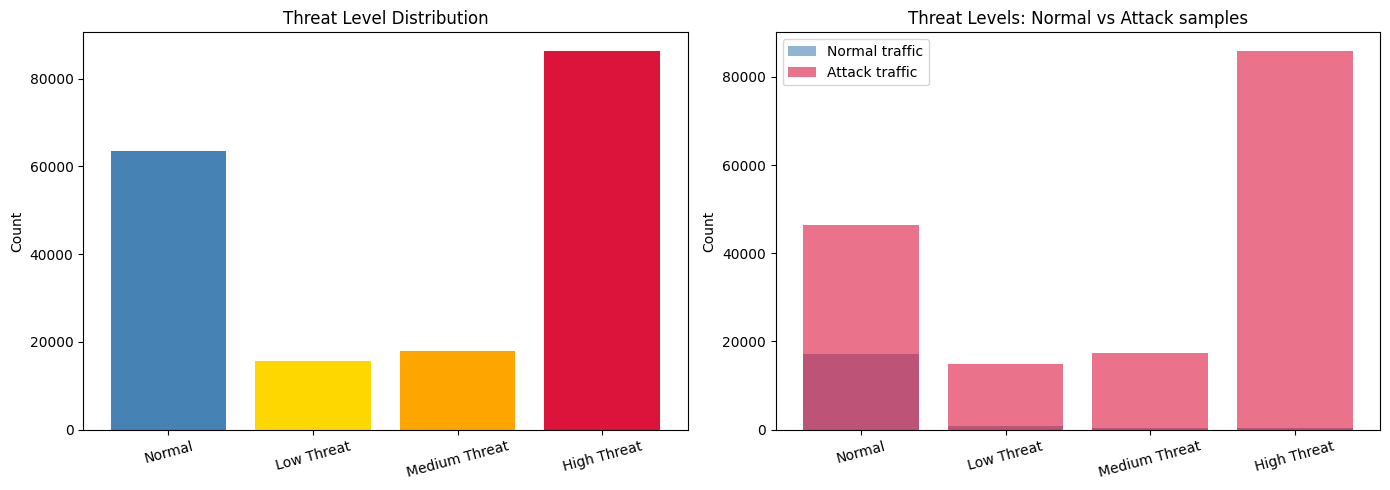

In [21]:
# visualize threat level distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

level_order = ['Normal', 'Low Threat', 'Medium Threat', 'High Threat']
level_colors = ['steelblue', 'gold', 'orange', 'crimson']

# overall counts
level_counts = pd.Series(threat_levels).value_counts().reindex(level_order, fill_value=0)
axes[0].bar(level_order, level_counts.values, color=level_colors)
axes[0].set_title('Threat Level Distribution')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

# per class
for cls, label in [(0, 'Normal'), (1, 'Attack')]:
    mask = y_test == cls
    sub_counts = pd.Series(threat_levels[mask]).value_counts().reindex(level_order, fill_value=0)
    axes[1].bar(level_order, sub_counts.values,
                alpha=0.6, label=label,
                color=['steelblue' if cls == 0 else 'crimson'] * 4)

axes[1].set_title('Threat Levels: Normal vs Attack samples')
axes[1].set_ylabel('Count')
axes[1].legend(['Normal traffic', 'Attack traffic'])
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 8. Baseline Model: Isolation Forest

To validate that the autoencoder is actually learning something useful, we compare it against Isolation Forest — a classic unsupervised anomaly detection method. Isolation Forest works by randomly partitioning the data: anomalies are easier to isolate and therefore have shorter average path lengths in the trees.

In [22]:
print("Training Isolation Forest...")
iso_forest = IsolationForest(
    n_estimators=300,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X_train_scaled)  # train only on normal data

# predict: Isolation Forest returns -1 for anomalies and 1 for normal
# we convert to 0 (normal) and 1 (anomaly) to match our label convention
iso_preds_raw = iso_forest.predict(X_test_scaled)
y_pred_iso = (iso_preds_raw == -1).astype(int)

# anomaly scores (lower = more anomalous in sklearn's convention)
iso_scores = -iso_forest.score_samples(X_test_scaled)  # negate so higher = more anomalous

print(f"Isolation Forest predictions: {(y_pred_iso==1).sum()} flagged as anomalies")

Training Isolation Forest...
Isolation Forest predictions: 46118 flagged as anomalies


## 9. Evaluation

We evaluate both models using the true labels. The labels are ONLY used here for evaluation — they were never used during training.

In [23]:
# side by side comparison table
from sklearn.metrics import roc_auc_score

comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Autoencoder': [
        accuracy_score(y_test, y_pred_ae),
        precision_score(y_test, y_pred_ae, zero_division=0),
        recall_score(y_test, y_pred_ae, zero_division=0),
        f1_score(y_test, y_pred_ae, zero_division=0),
        roc_auc_score(y_test, test_errors)
    ],
    'Isolation Forest': [
        accuracy_score(y_test, y_pred_iso),
        precision_score(y_test, y_pred_iso, zero_division=0),
        recall_score(y_test, y_pred_iso, zero_division=0),
        f1_score(y_test, y_pred_iso, zero_division=0),
        roc_auc_score(y_test, iso_scores)
    ]
})

comparison = comparison.set_index('Metric').round(4)
print(comparison.to_string())

           Autoencoder  Isolation Forest
Metric                                  
Accuracy        0.7383            0.3432
Precision       0.9875            0.9802
Recall          0.7179            0.2745
F1 Score        0.8314            0.4289
ROC-AUC         0.8841            0.7857


## 10. Visualizations

### 10.1 Confusion Matrices

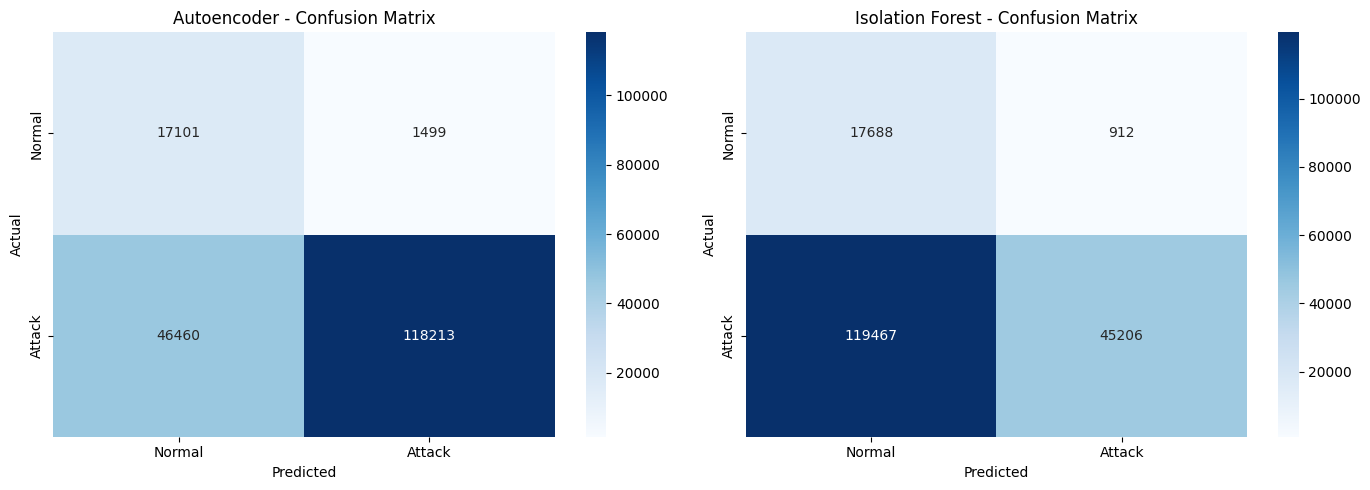

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name in zip(axes,
                            [y_pred_ae, y_pred_iso],
                            ['Autoencoder', 'Isolation Forest']):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Normal', 'Attack'],
                yticklabels=['Normal', 'Attack'])
    ax.set_title(f'{name} - Confusion Matrix')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

### 10.2 ROC Curves

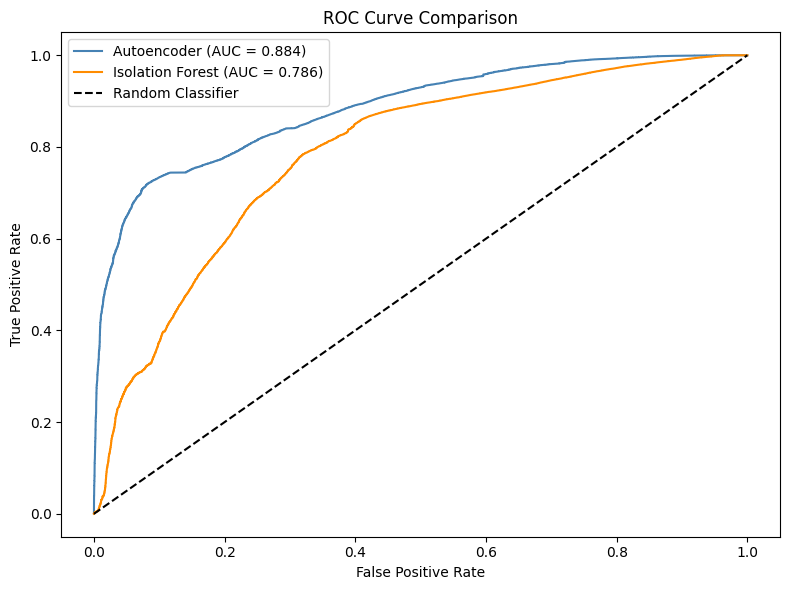

In [25]:
plt.figure(figsize=(8, 6))

for scores, name, color in [
    (test_errors, 'Autoencoder', 'steelblue'),
    (iso_scores, 'Isolation Forest', 'darkorange')
]:
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc = roc_auc_score(y_test, scores)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.tight_layout()
plt.show()

### 10.3 Reconstruction Error Distribution

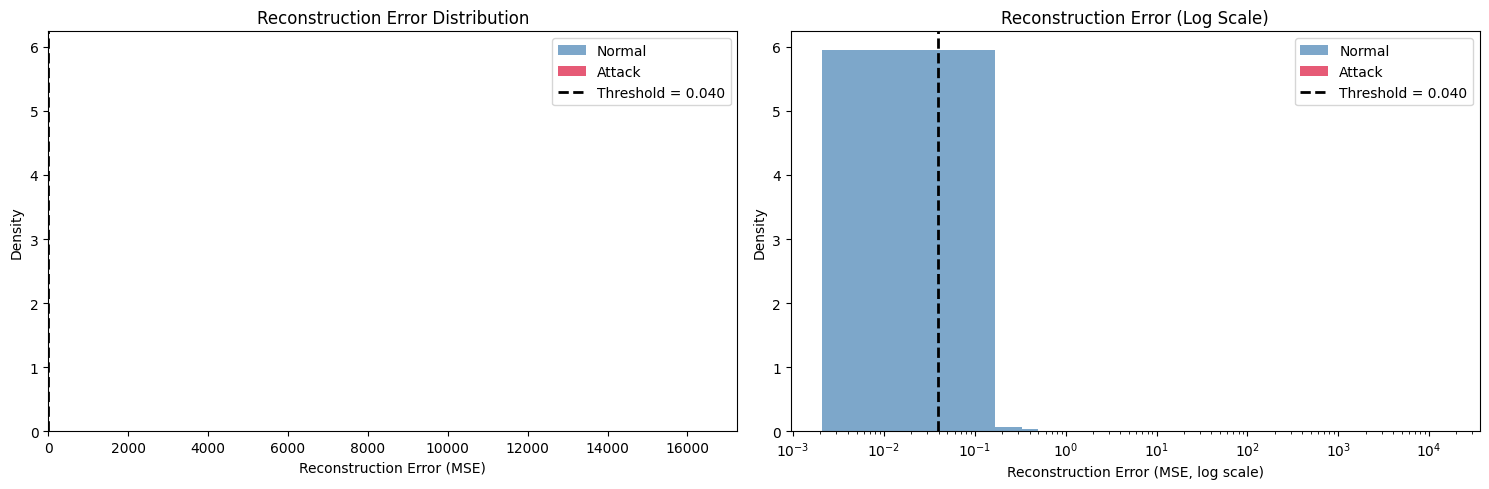

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# histogram (log scale on x-axis helps when errors span orders of magnitude)
axes[0].hist(test_errors[y_test == 0], bins=80, alpha=0.7,
             label='Normal', color='steelblue', density=True)
axes[0].hist(test_errors[y_test == 1], bins=80, alpha=0.7,
             label='Attack', color='crimson', density=True)
axes[0].axvline(threshold, color='black', linestyle='--',
                linewidth=2, label=f'Threshold = {threshold:.3f}')
axes[0].set_xlabel('Reconstruction Error (MSE)')
axes[0].set_ylabel('Density')
axes[0].set_title('Reconstruction Error Distribution')
axes[0].legend()
axes[0].set_xlim(left=0)

# log scale version — helps see separation in the tail
axes[1].hist(test_errors[y_test == 0], bins=80, alpha=0.7,
             label='Normal', color='steelblue', density=True)
axes[1].hist(test_errors[y_test == 1], bins=80, alpha=0.7,
             label='Attack', color='crimson', density=True)
axes[1].axvline(threshold, color='black', linestyle='--',
                linewidth=2, label=f'Threshold = {threshold:.3f}')
axes[1].set_xlabel('Reconstruction Error (MSE, log scale)')
axes[1].set_ylabel('Density')
axes[1].set_title('Reconstruction Error (Log Scale)')
axes[1].set_xscale('log')
axes[1].legend()

plt.tight_layout()
plt.show()

## 11. Explainability: Which Features Drive Anomalies?

For anomalous samples, we look at which individual features had the highest squared reconstruction error. This tells us what is "abnormal" about the flagged traffic — useful for an analyst trying to understand an alert.

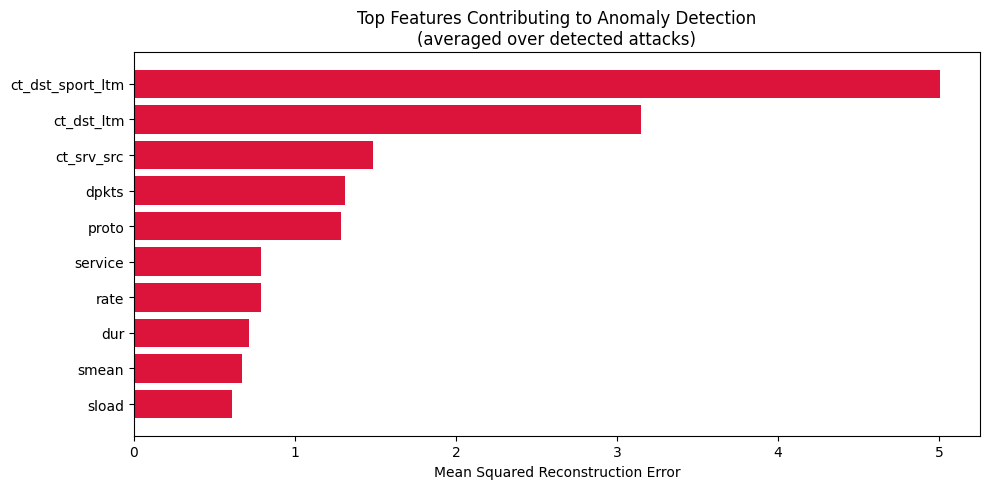

Top contributing features for detected attacks:
  ct_dst_sport_ltm              : 5.0056
  ct_dst_ltm                    : 3.1494
  ct_srv_src                    : 1.4845
  dpkts                         : 1.3113
  proto                         : 1.2840
  service                       : 0.7915
  rate                          : 0.7914
  dur                           : 0.7135
  smean                         : 0.6739
  sload                         : 0.6066


In [27]:
def explain_anomaly(model, X_scaled, feature_names, sample_indices, n_top=10):
    """
    For a set of anomalous samples, computes per-feature reconstruction error
    and averages them to find which features are consistently hardest to reconstruct.
    
    In practice, you'd run this for each individual alert, not an average.
    """
    X_sample = X_scaled[sample_indices]
    X_recon  = model.predict(X_sample, verbose=0)
    
    # per-feature squared error averaged across the selected samples
    feature_errors = np.mean(np.power(X_sample - X_recon, 2), axis=0)
    
    # sort by contribution
    top_idx = np.argsort(feature_errors)[::-1][:n_top]
    top_features = [feature_names[i] for i in top_idx]
    top_errors   = feature_errors[top_idx]
    
    return top_features, top_errors


feature_names = list(df_clean.columns)

# select a sample of true positive detections (actual attacks that we flagged)
true_positive_idx = np.where((y_test == 1) & (y_pred_ae == 1))[0]
# select a sample of false negatives (missed attacks) for comparison
false_negative_idx = np.where((y_test == 1) & (y_pred_ae == 0))[0]

if len(true_positive_idx) > 0:
    sample_tp = true_positive_idx[:min(100, len(true_positive_idx))]
    tp_features, tp_errors = explain_anomaly(autoencoder, X_test_scaled, feature_names, sample_tp)
    
    plt.figure(figsize=(10, 5))
    plt.barh(tp_features[::-1], tp_errors[::-1], color='crimson')
    plt.xlabel('Mean Squared Reconstruction Error')
    plt.title('Top Features Contributing to Anomaly Detection\n(averaged over detected attacks)')
    plt.tight_layout()
    plt.show()
    
    print("Top contributing features for detected attacks:")
    for feat, err in zip(tp_features, tp_errors):
        print(f"  {feat:30s}: {err:.4f}")
else:
    print("No true positives found in this sample.")

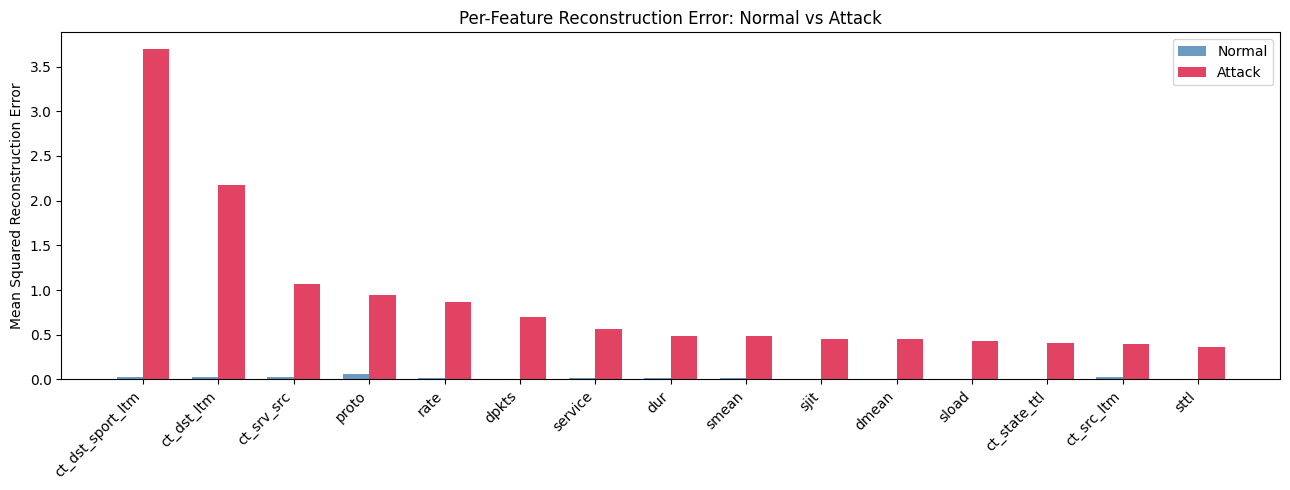

In [28]:
# compare feature error profiles between normal and attack traffic
normal_test_idx = np.where(y_test == 0)[0][:200]
attack_test_idx = np.where(y_test == 1)[0][:200]

X_norm_sample   = X_test_scaled[normal_test_idx]
X_attack_sample = X_test_scaled[attack_test_idx]

recon_norm   = autoencoder.predict(X_norm_sample, verbose=0)
recon_attack = autoencoder.predict(X_attack_sample, verbose=0)

feature_err_norm   = np.mean(np.power(X_norm_sample - recon_norm, 2), axis=0)
feature_err_attack = np.mean(np.power(X_attack_sample - recon_attack, 2), axis=0)

# pick top features by attack error
top_n = 15
top_idx = np.argsort(feature_err_attack)[::-1][:top_n]
top_names = [feature_names[i] for i in top_idx]

x = np.arange(top_n)
width = 0.35

fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width/2, feature_err_norm[top_idx], width, label='Normal', color='steelblue', alpha=0.8)
ax.bar(x + width/2, feature_err_attack[top_idx], width, label='Attack', color='crimson', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top_names, rotation=45, ha='right')
ax.set_ylabel('Mean Squared Reconstruction Error')
ax.set_title('Per-Feature Reconstruction Error: Normal vs Attack')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Zero-Day Attack Detection

A key advantage of the unsupervised approach is that it can detect attack types it has never seen before — so-called zero-day attacks. We simulate this by holding out specific attack categories from the test set and checking if the model can still detect them.

In [29]:
if attack_cat is not None:
    # get attack categories in the test set
    test_attack_cats = attack_cat[test_shuffle_idx]
    
    unique_attack_cats = np.unique(test_attack_cats[y_test == 1])
    print("Attack categories present in test set:")
    print(unique_attack_cats)
    print()
    
    results = []
    for cat in unique_attack_cats:
        if cat == 'Normal':
            continue
        
        # find samples of this specific attack type in the test set
        cat_mask = (test_attack_cats == cat) & (y_test == 1)
        if cat_mask.sum() == 0:
            continue
        
        cat_errors = test_errors[cat_mask]
        detected = (cat_errors > threshold).sum()
        detection_rate = detected / len(cat_errors)
        
        results.append({
            'Attack Category': cat,
            'Total Samples': len(cat_errors),
            'Detected': detected,
            'Detection Rate': f'{detection_rate:.1%}',
            'Mean Error': f'{cat_errors.mean():.4f}'
        })
    
    if results:
        results_df = pd.DataFrame(results)
        print("Zero-Day Style Detection by Attack Category:")
        print(results_df.to_string(index=False))
else:
    # synthetic data fallback: pretend we have two unseen attack types
    print("Simulating zero-day detection with synthetic unseen attack types...")
    
    # generate two synthetic 'novel' attack distributions not present in training
    np.random.seed(99)
    n_novel = 300
    
    # attack type 1: unusually high packet rate (like a DDoS variant)
    X_novel_1 = X_train_scaled.mean(axis=0) + np.random.normal(3, 0.5, (n_novel, X_train_scaled.shape[1]))
    # attack type 2: very unusual combination of features (like a novel protocol exploit)
    X_novel_2 = X_train_scaled.mean(axis=0) * np.random.uniform(-2, 5, (n_novel, X_train_scaled.shape[1]))
    
    err_novel_1 = compute_reconstruction_error(autoencoder, X_novel_1)
    err_novel_2 = compute_reconstruction_error(autoencoder, X_novel_2)
    
    det_1 = (err_novel_1 > threshold).mean()
    det_2 = (err_novel_2 > threshold).mean()
    
    print(f"Novel Attack Type 1 (high-rate DDoS variant) - Detection rate: {det_1:.1%}")
    print(f"Novel Attack Type 2 (protocol exploit variant) - Detection rate: {det_2:.1%}")
    print("\nThis demonstrates that even without seeing these attack types during training,")
    print("the model can detect them because they deviate from normal traffic patterns.")

Attack categories present in test set:
['Analysis' 'Backdoor' 'DoS' 'Exploits' 'Fuzzers' 'Generic' 'Normal'
 'Reconnaissance' 'Shellcode' 'Worms']

Zero-Day Style Detection by Attack Category:
Attack Category  Total Samples  Detected Detection Rate Mean Error
       Analysis           2151      1501          69.8%     0.5672
       Backdoor           1795      1292          72.0%     1.4558
            DoS          14433     10666          73.9%     0.6303
       Exploits          36695     26887          73.3%     0.7638
        Fuzzers          19168     14058          73.3%     1.5619
        Generic          40000     32175          80.4%     1.0966
 Reconnaissance          11423      8433          73.8%     0.7938
      Shellcode           1223       893          73.0%     0.8757
          Worms            142       103          72.5%     0.3851


## 13. Why Anomaly Detection Over Classification for Defence?

Supervised classification needs labeled examples of every attack type to detect it. In defence contexts:

1. **New attacks appear constantly** — zero-day exploits and novel TTPs (tactics, techniques, procedures) are by definition not in any training set.

2. **Attack data is scarce** — labeled attack samples are hard to obtain, especially for advanced persistent threats (APTs) that move slowly to avoid detection.

3. **Normal behavior is definable** — it is much easier to characterize what normal communication looks like for a specific network than to enumerate all possible attacks.

4. **Adversarial adaptation** — if attackers know a classifier exists, they can craft traffic that evades its specific boundaries. Anomaly detection is harder to evade because the attacker doesn't know exactly what "normal" looks like to the model.

The tradeoff is more false positives — anomaly detection flags things that are unusual but not necessarily malicious. Threat level tiering (Section 7) helps manage this.

## 14. LSTM Autoencoder for Temporal Analysis (Optional Extension)

Network traffic is a time series. Individual packet features matter, but so does the sequence of traffic over time. An LSTM autoencoder treats traffic as sequences and can detect temporal anomalies that a standard feed-forward autoencoder misses (e.g. a slow-moving port scan).

In [30]:
def build_lstm_autoencoder(timesteps, n_features, encoding_dim=16):
    """
    LSTM autoencoder. The encoder reads a sequence and compresses it to a 
    single vector. The decoder expands that back to the original sequence.
    """
    inputs = keras.Input(shape=(timesteps, n_features))
    
    # encoder: two LSTM layers, we keep only the final state
    x = layers.LSTM(32, activation='tanh', return_sequences=True)(inputs)
    encoded = layers.LSTM(encoding_dim, activation='tanh', return_sequences=False)(x)
    
    # repeat the bottleneck vector for each timestep in the output sequence
    x = layers.RepeatVector(timesteps)(encoded)
    
    # decoder: mirrors encoder, return_sequences=True to output full sequence
    x = layers.LSTM(encoding_dim, activation='tanh', return_sequences=True)(x)
    x = layers.LSTM(32, activation='tanh', return_sequences=True)(x)
    outputs = layers.TimeDistributed(layers.Dense(n_features, activation='linear'))(x)
    
    model = keras.Model(inputs, outputs, name='lstm_autoencoder')
    model.compile(optimizer='adam', loss='mse')
    return model


def create_sequences(X, timesteps=10):
    """
    Converts a 2D feature matrix into 3D sequences for LSTM input.
    Each row becomes a context window of 'timesteps' consecutive rows.
    This assumes the data has some temporal ordering (e.g. by connection time).
    """
    sequences = []
    for i in range(len(X) - timesteps + 1):
        sequences.append(X[i:i + timesteps])
    return np.array(sequences)


TIMESTEPS = 10
n_features = X_train_scaled.shape[1]

# create sequence data
X_train_seq = create_sequences(X_train_scaled, TIMESTEPS)
X_test_seq  = create_sequences(X_test_scaled,  TIMESTEPS)
# align labels with sequences (label of a sequence = label of its last element)
y_test_seq  = y_test[TIMESTEPS - 1:]

print(f"Training sequences shape: {X_train_seq.shape}")
print(f"Test sequences shape:     {X_test_seq.shape}")

lstm_ae = build_lstm_autoencoder(TIMESTEPS, n_features, encoding_dim=16)
lstm_ae.summary()

Training sequences shape: (74391, 10, 30)
Test sequences shape:     (183264, 10, 30)


Model: "lstm_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 10, 30)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 10, 32)         │         8,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector (RepeatVector)    │ (None, 10, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 10, 16)         │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 10, 32)         │         6,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 10, 30)         │           990 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,574 (80.37 KB)

 Trainable params: 20,574 (80.37 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
# train LSTM autoencoder — this takes longer than the dense one
early_stop_lstm = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

lstm_history = lstm_ae.fit(
    X_train_seq, X_train_seq,
    epochs=50,
    batch_size=128,
    validation_split=0.15,
    callbacks=[early_stop_lstm],
    verbose=1
)

print(f"LSTM training done. Stopped at epoch {len(lstm_history.history['loss'])}.")

Epoch 1/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - loss: 0.9320 - val_loss: 0.8761
Epoch 2/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.8300 - val_loss: 0.7772
Epoch 3/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 12s 24ms/step - loss: 0.7557 - val_loss: 0.7176
Epoch 4/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - loss: 0.7098 - val_loss: 0.6832
Epoch 5/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - loss: 0.6833 - val_loss: 0.6615
Epoch 6/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 0.6641 - val_loss: 0.6453
Epoch 7/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.6489 - val_loss: 0.6328
Epoch 8/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - loss: 0.6367 - val_loss: 0.6222
Epoch 9/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.6268 - val_loss: 0.6127
Epoch 10/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 0.6183 - val_loss: 0.6048
Epoch 11/50
494/494 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - loss: 0.6108 - val_loss: 0.5987
Epoch 12/50
494/494 ━━━━━━━━━━

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

def evaluate_model(y_true, y_pred, scores, model_name):
    print("="*50)
    print(f"Model: {model_name}")
    print("="*50)
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, scores):.4f}")
    print()
    print("Classification Report:")
    print(classification_report(y_true, y_pred))
# reconstruct and compute sequence-level error
X_test_seq_recon = lstm_ae.predict(X_test_seq, verbose=0)
# error per sequence: mean over both timesteps and features
lstm_test_errors = np.mean(np.power(X_test_seq - X_test_seq_recon, 2), axis=(1, 2))

# calibrate threshold using training sequences
X_train_seq_recon = lstm_ae.predict(X_train_seq, verbose=0)
lstm_train_errors = np.mean(np.power(X_train_seq - X_train_seq_recon, 2), axis=(1, 2))

lstm_threshold = np.percentile(lstm_train_errors, 92)
y_pred_lstm = (lstm_test_errors > lstm_threshold).astype(int)

print("LSTM Autoencoder Evaluation:")
evaluate_model(y_test_seq, y_pred_lstm, lstm_test_errors, 'LSTM Autoencoder')

LSTM Autoencoder Evaluation:
Model: LSTM Autoencoder
Accuracy : 0.8013
Precision: 0.9030
Recall   : 0.8726
F1 Score : 0.8875
ROC-AUC  : 0.5481

Classification Report:
              precision    recall  f1-score   support

           0       0.13      0.17      0.15     18600
           1       0.90      0.87      0.89    164664

    accuracy                           0.80    183264
   macro avg       0.52      0.52      0.52    183264
weighted avg       0.82      0.80      0.81    183264



In [33]:
# final comparison including LSTM
models = ['Autoencoder (Dense)', 'Isolation Forest', 'LSTM Autoencoder']
preds  = [y_pred_ae, y_pred_iso, y_pred_lstm]
scores = [test_errors, iso_scores, lstm_test_errors]
y_true_list = [y_test, y_test, y_test_seq]

final_comparison = []
for model_name, yp, s, yt in zip(models, preds, scores, y_true_list):
    final_comparison.append({
        'Model': model_name,
        'Accuracy': round(accuracy_score(yt, yp), 4),
        'Precision': round(precision_score(yt, yp, zero_division=0), 4),
        'Recall': round(recall_score(yt, yp, zero_division=0), 4),
        'F1': round(f1_score(yt, yp, zero_division=0), 4),
        'ROC-AUC': round(roc_auc_score(yt, s), 4)
    })

print("Final Model Comparison:")
print(pd.DataFrame(final_comparison).set_index('Model').to_string())

Final Model Comparison:
                     Accuracy  Precision  Recall      F1  ROC-AUC
Model                                                            
Autoencoder (Dense)    0.7383     0.9875  0.7179  0.8314   0.8841
Isolation Forest       0.3432     0.9802  0.2745  0.4289   0.7857
LSTM Autoencoder       0.8013     0.9030  0.8726  0.8875   0.5481


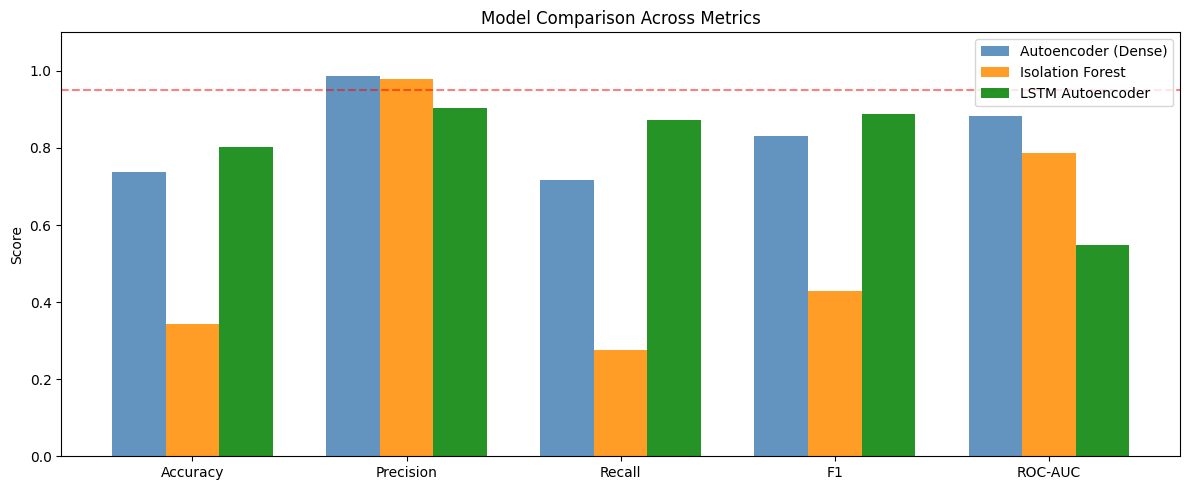

In [34]:
# bar chart for model comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
comp_df = pd.DataFrame(final_comparison).set_index('Model')

x = np.arange(len(metrics))
width = 0.25
colors = ['steelblue', 'darkorange', 'green']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (model_name, row) in enumerate(comp_df.iterrows()):
    ax.bar(x + i * width, [row[m] for m in metrics], width,
           label=model_name, color=colors[i], alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Comparison Across Metrics')
ax.legend()
ax.axhline(y=0.95, color='red', linestyle='--', alpha=0.5, label='0.95 target')
plt.tight_layout()
plt.show()

## 15. Defence Context and Real-World Applicability

### How This Applies to Defence Communication Networks

Defence networks — military communication infrastructure, command-and-control systems, satellite uplinks — face threats from nation-state actors who use sophisticated, targeted attack methods. Unlike corporate networks, the stakes are much higher and the attack surface is more constrained (traffic patterns are more predictable, which actually helps anomaly detection).

This system would be deployed as a network sensor, sitting on a SPAN port or network tap, processing traffic in near real-time:

1. **Training phase**: Capture several weeks of normal operational traffic and train the autoencoder on it. The model learns the baseline communication patterns — which protocols are used, typical packet sizes, connection durations, etc.

2. **Detection phase**: Process live traffic through the trained model. Connections with high reconstruction error are flagged for review.

3. **Triage**: The threat level output routes alerts to appropriate responders — low threats go to a log for periodic review, high threats trigger immediate alerts to a security operations center.

### Role in Detecting Cyber Warfare Attacks

Cyber warfare operations often use techniques that blend into normal traffic to avoid signature-based detection. Common examples:

- **Covert channels**: Data exfiltrated using DNS queries or HTTP headers. These look like normal protocol usage but have unusual byte patterns or timing.
- **Living off the land**: Using legitimate system tools (like PowerShell) for lateral movement. The network traffic may be encrypted but the volume and timing differ from normal administrative activity.
- **APT beaconing**: Malware that calls home on a schedule. Even if the individual connections look normal, the regularity and timing are anomalous.

Autoencoder-based detection can catch all of these because they alter the statistical properties of network traffic, even if no known signature matches.

### Importance of Zero-Day Detection

Adversaries in nation-state contexts invest significant resources in developing exploits that are unknown to defenders. By definition, signature-based systems and supervised classifiers cannot detect these. Anomaly detection provides a first layer of defense that doesn't depend on prior knowledge of the attack method.

### Limitations in Real-World Deployment

This system has real limitations that need to be acknowledged:

1. **False positive fatigue**: Even a 5% false positive rate generates thousands of alerts per day on a busy network. Alert routing and tiering (as implemented here) helps, but analyst capacity is finite.

2. **Concept drift**: Normal traffic patterns change over time as new applications are deployed, new users come on, and operational patterns shift. The model needs periodic retraining to stay current.

3. **Adversarial evasion**: A sophisticated attacker with knowledge of the anomaly detection system could craft traffic that blends with the learned normal distribution. This is harder than evading signature systems but not impossible.

4. **Encrypted traffic**: Modern network traffic is increasingly encrypted. The model works on packet metadata (sizes, timing, counts) rather than content, but deep inspection is not possible without decryption infrastructure.

5. **No attribution**: Anomaly detection tells you something is wrong but not who is doing it or why. It is one component of a broader defence-in-depth strategy, not a complete solution.

## 16. Summary

What we built and why each piece matters:

| Component | Choice | Reason |
|-----------|--------|--------|
| Dataset | UNSW-NB15 | Realistic network intrusion dataset with diverse attack types |
| Training strategy | Normal traffic only | Enables detection of unknown attacks |
| Preprocessing | Variance filter + correlation removal + scaling | Removes noise, speeds up training, improves accuracy |
| Model | Dense Autoencoder | Learns compact representation of normal traffic |
| Threshold | Mean + k*std on training errors | Statistically principled, tunable |
| Baseline | Isolation Forest | Classical method for comparison |
| Extension | LSTM Autoencoder | Captures temporal patterns in traffic sequences |
| Explainability | Per-feature reconstruction error | Helps analysts understand what triggered an alert |
| Threat levels | Three-tier (Low/Medium/High) | Supports operational triage |

The core insight is: **if you build a model that knows what normal looks like, anything that doesn't look normal is worth investigating** — including attacks that have never been seen before.

## Synthetic Defence Attack Simulation & Explainability

To enhance the practical relevance of this system, synthetic attack scenarios were generated to simulate defence-oriented threats such as Denial-of-Service (DoS) and data exfiltration.

These attacks are created by modifying key network features such as byte count and duration to reflect realistic adversarial behavior.

Additionally, a feature-level explainability mechanism is implemented to identify which attributes contribute most to anomalous behavior. This improves interpretability and supports real-world decision-making in defence systems.

In [35]:
# Function to generate synthetic attack samples for DoS and Data Exfiltration
import numpy as np
import pandas as pd

def generate_synthetic_attacks(X, n_samples=5000, dos_ratio=0.5, random_state=42):
    np.random.seed(random_state)
    synth_attacks = []
    n_dos = int(n_samples * dos_ratio)
    n_exfil = n_samples - n_dos

    # Identify likely relevant columns
    byte_cols = [col for col in X.columns if 'byte' in col.lower()]
    dur_cols = [col for col in X.columns if 'dur' in col.lower() or 'time' in col.lower()]
    # Fallbacks if not found
    if not byte_cols:
        byte_cols = [col for col in X.columns if X[col].max() > 10000]
    if not dur_cols:
        dur_cols = [col for col in X.columns if X[col].max() > 10 and X[col].min() >= 0]

    # DoS: high bytes, low duration
    rows = X.sample(n_dos, replace=True).copy()
    for col in byte_cols:
        rows[col] = rows[col] * np.random.uniform(5, 15, size=n_dos)
        rows[col] = np.clip(rows[col], 0, X[col].quantile(0.99))

    for col in dur_cols:
        rows[col] = rows[col] * np.random.uniform(0.01, 0.2, size=n_dos)

    synth_attacks.append(rows)

    # Exfiltration: high bytes, long duration
    rows_exfil = X.sample(n_exfil, replace=True).copy()

    for col in byte_cols:
        rows_exfil[col] = rows_exfil[col] * np.random.uniform(3, 8, size=n_exfil)
        rows_exfil[col] = np.clip(rows_exfil[col], 0, X[col].quantile(0.99))

    for col in dur_cols:
        rows_exfil[col] = rows_exfil[col] * np.random.uniform(2, 6, size=n_exfil)
        rows_exfil[col] = np.clip(rows_exfil[col], 0, X[col].quantile(0.99))

    synth_attacks.append(rows_exfil)

    synth_df = pd.concat(synth_attacks, ignore_index=True)
    synth_df = synth_df[X.columns]  # preserve column order
    return synth_df
X_test_df = pd.DataFrame(X_test, columns=feature_names)
# Generate synthetic attacks and extend test set
X_synth = generate_synthetic_attacks(X_test_df, n_samples=5000)
y_synth = np.ones(len(X_synth), dtype=int)
X_test_extended = pd.concat([X_test_df, X_synth], ignore_index=True)
y_test_extended = np.concatenate([y_test, y_synth])

# SCALE extended test data FIRST
X_test_extended_scaled = scaler.transform(X_test_extended)

# Predict on scaled data
X_test_pred_ext = autoencoder.predict(X_test_extended_scaled)

# Compute reconstruction error correctly
test_errors_ext = np.mean(
    np.square(X_test_extended_scaled - X_test_pred_ext),
    axis=1
)

# Classification
y_pred_ae_ext = (test_errors_ext > threshold).astype(int)

# Example evaluation (update metrics as needed)
from sklearn.metrics import classification_report
print(classification_report(y_test_extended, y_pred_ae_ext, target_names=["Normal", "Attack"]))

5884/5884 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
              precision    recall  f1-score   support

      Normal       0.27      0.92      0.41     18600
      Attack       0.99      0.72      0.84    169673

    accuracy                           0.74    188273
   macro avg       0.63      0.82      0.62    188273
weighted avg       0.92      0.74      0.79    188273



In [36]:
# Function to explain anomaly by top-N feature errors
def explain_anomaly(x, x_pred, feature_names, top_n=3):
    errors = np.abs(x - x_pred)
    top_idx = np.argsort(errors)[::-1][:top_n]
    print("Top contributing features to anomaly:")
    for idx in top_idx:
        print(f"  {feature_names[idx]}: error = {errors[idx]:.4f}")

# Example: explain one detected anomaly from extended set
anomaly_indices = np.where(y_pred_ae_ext == 1)[0]
if len(anomaly_indices) > 0:
    idx = anomaly_indices[0]
    print(f"Explaining anomaly at index {idx} (extended set):")
    explain_anomaly(
    X_test_extended_scaled[idx],   
    X_test_pred_ext[idx],
    feature_names=X_test_extended.columns,
    top_n=3
)
else:
    print("No anomalies detected to explain.")

Explaining anomaly at index 1 (extended set):
Top contributing features to anomaly:
  service: error = 1.4986
  sttl: error = 0.6505
  ct_src_ltm: error = 0.5844


In [37]:
# SCALE extended test data FIRST
X_test_extended_scaled = scaler.transform(X_test_extended)

# Predict on scaled data
X_test_pred_ext = autoencoder.predict(X_test_extended_scaled)

# Compute reconstruction error correctly
test_errors_ext = np.mean(
    np.square(X_test_extended_scaled - X_test_pred_ext),
    axis=1
)

# Classification
y_pred_ae_ext = (test_errors_ext > threshold).astype(int)

# Example evaluation (update metrics as needed)
from sklearn.metrics import classification_report
print(classification_report(y_test_extended, y_pred_ae_ext, target_names=["Normal", "Attack"]))

5884/5884 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
              precision    recall  f1-score   support

      Normal       0.27      0.92      0.41     18600
      Attack       0.99      0.72      0.84    169673

    accuracy                           0.74    188273
   macro avg       0.63      0.82      0.62    188273
weighted avg       0.92      0.74      0.79    188273

